# Hacker News Sentiment Toward Generative AI, 2022–2026

**CS439 Final Project — Analysis Notebook**

This notebook collects the headline figures and findings from our analysis of how the Hacker News community has talked about generative AI between January 2022 and April 2026. All figures are pre-rendered by `python -m src.figures` from the pipeline outputs in `results/`. The companion document `REPORT_BRIEF.md` walks through everything in plain English for the report.

The pipeline measures **five orthogonal signals** for every post / comment in the corpus:

1. **RoBERTa polarity** — a transformer model fine-tuned on Twitter, gives a signed score in [−1, +1].
2. **VADER polarity** — a classic social-media sentiment lexicon (compound score in [−1, +1]).
3. **AFINN polarity** — a simpler lexicon baseline (per-word mean).
4. **NRC emotion frequencies** — eight emotion categories (anger, anticipation, disgust, fear, joy, sadness, surprise, trust) plus aggregate positive/negative.
5. **Hedge density** — fraction of sentences that contain an epistemic-uncertainty marker ("maybe", "I think", "could", etc.).

Corpus: 46,387 top-30-per-day items (8,623 stories, 38,445 comments) drawn from a population of 656,980 AI-related Hacker News items, filtered with ~39 generative-AI keyword patterns.

**A note on reading the figures.** Each figure section below has three parts: a one-line description of *what is plotted*, a short bullet list of *what to look for*, and a takeaway *what we see*. The first two help you form your own interpretation before reading ours.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

RESULTS = Path('../results')
FIGS = RESULTS / 'figures'
PROC = Path('../data/processed')

def show(name):
    display(Image(filename=str(FIGS / name)))

## 1. Headline trajectory

**What is plotted.** Mean RoBERTa sentiment per week, January 2022 to April 2026. Shaded band = ±1 standard error. Red dashed lines mark named AI events. Green dotted lines are change-point dates detected by the PELT algorithm at the strictest penalty.

**What to look for.**
- Where does the line sit relative to the horizontal zero line? Below = net negative, above = net positive.
- Is there a clear trend (drift up, down, or flat)? Compare the 2022 left edge to the 2026 right edge.
- Do any visible inflection points line up with red event lines?

**What we see.** Sentiment hovers near zero through 2022–2024, then drifts negative starting in 2025. The most negative period of the entire window is **late 2025–early 2026** (around −0.15 to −0.20). The picture is not "AI hate" — it's measurable cooling.

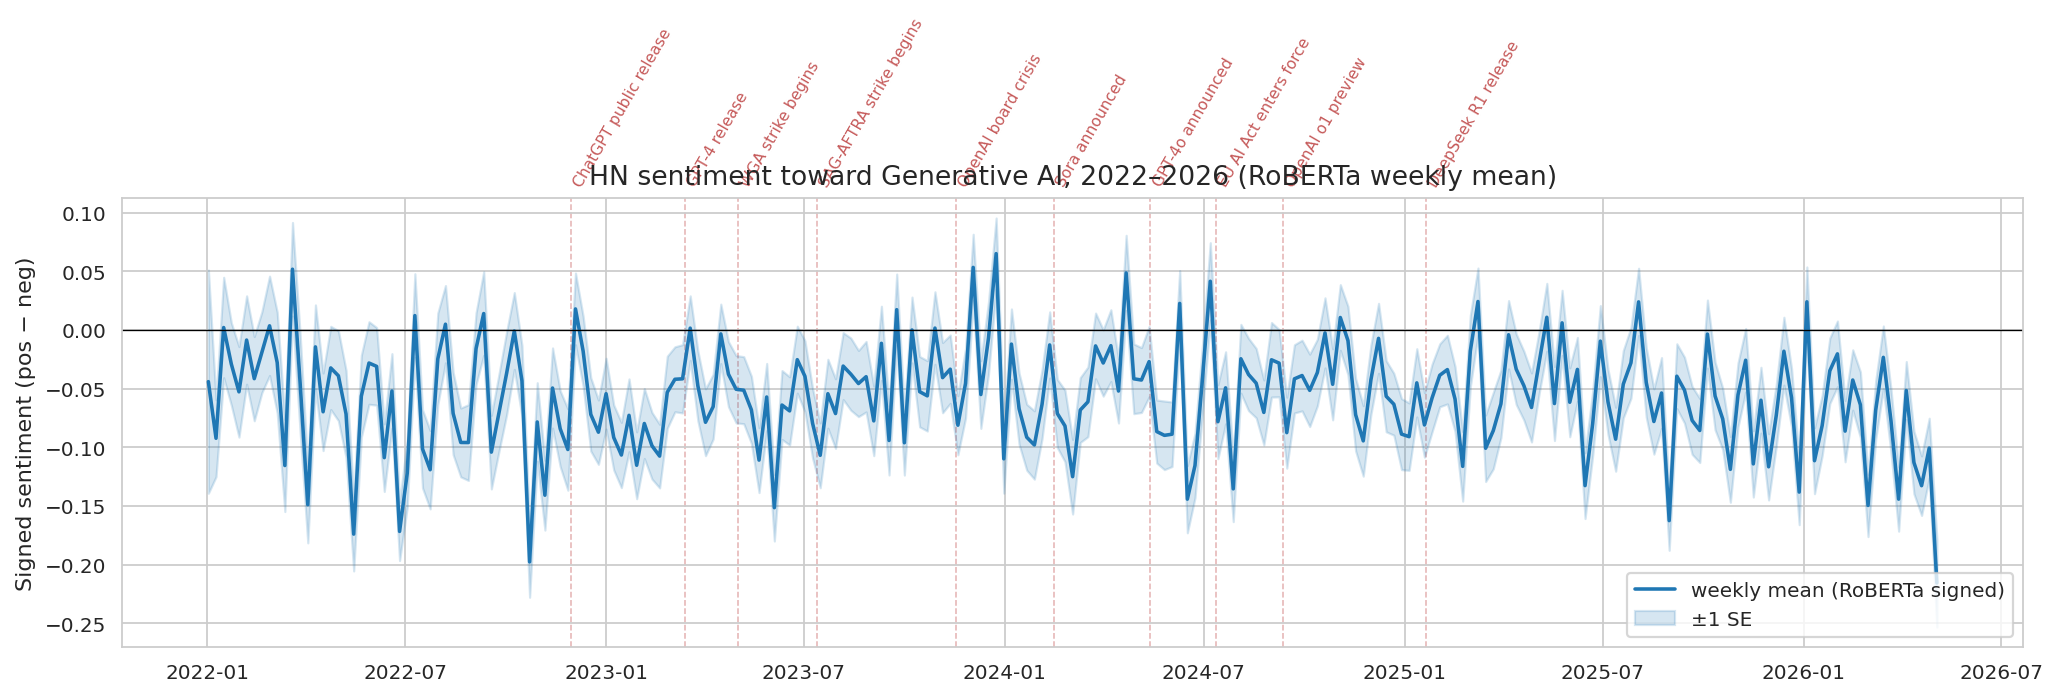

In [2]:
show('01_headline_sentiment.png')

## 2. The three polarity scorers tell different stories

**What is plotted.** The same period, scored three different ways: RoBERTa (top), VADER (middle), AFINN (bottom). Same x-axis; each has its own y-scale.

**What to look for.**
- Compare the y-axis ranges. RoBERTa moves through ~0.3 of range; VADER stays in a narrow band near +0.5; AFINN sits between.
- Does each scorer agree on the *direction* of trend?
- VADER's near-flat trace is the diagnostic — when a tool gives the same answer always, it's not measuring what we think.

**What we see.** RoBERTa drifts negative — credible. VADER is pinned near +0.5 the entire time, which is **VADER's known saturation pathology** on long-form text (its compound formula was tuned for tweets and breaks on paragraph-length comments). AFINN sits in the middle, slightly positive. Picking a single sentiment model would have changed the conclusion. We use RoBERTa as primary; the disagreement *is* a finding.

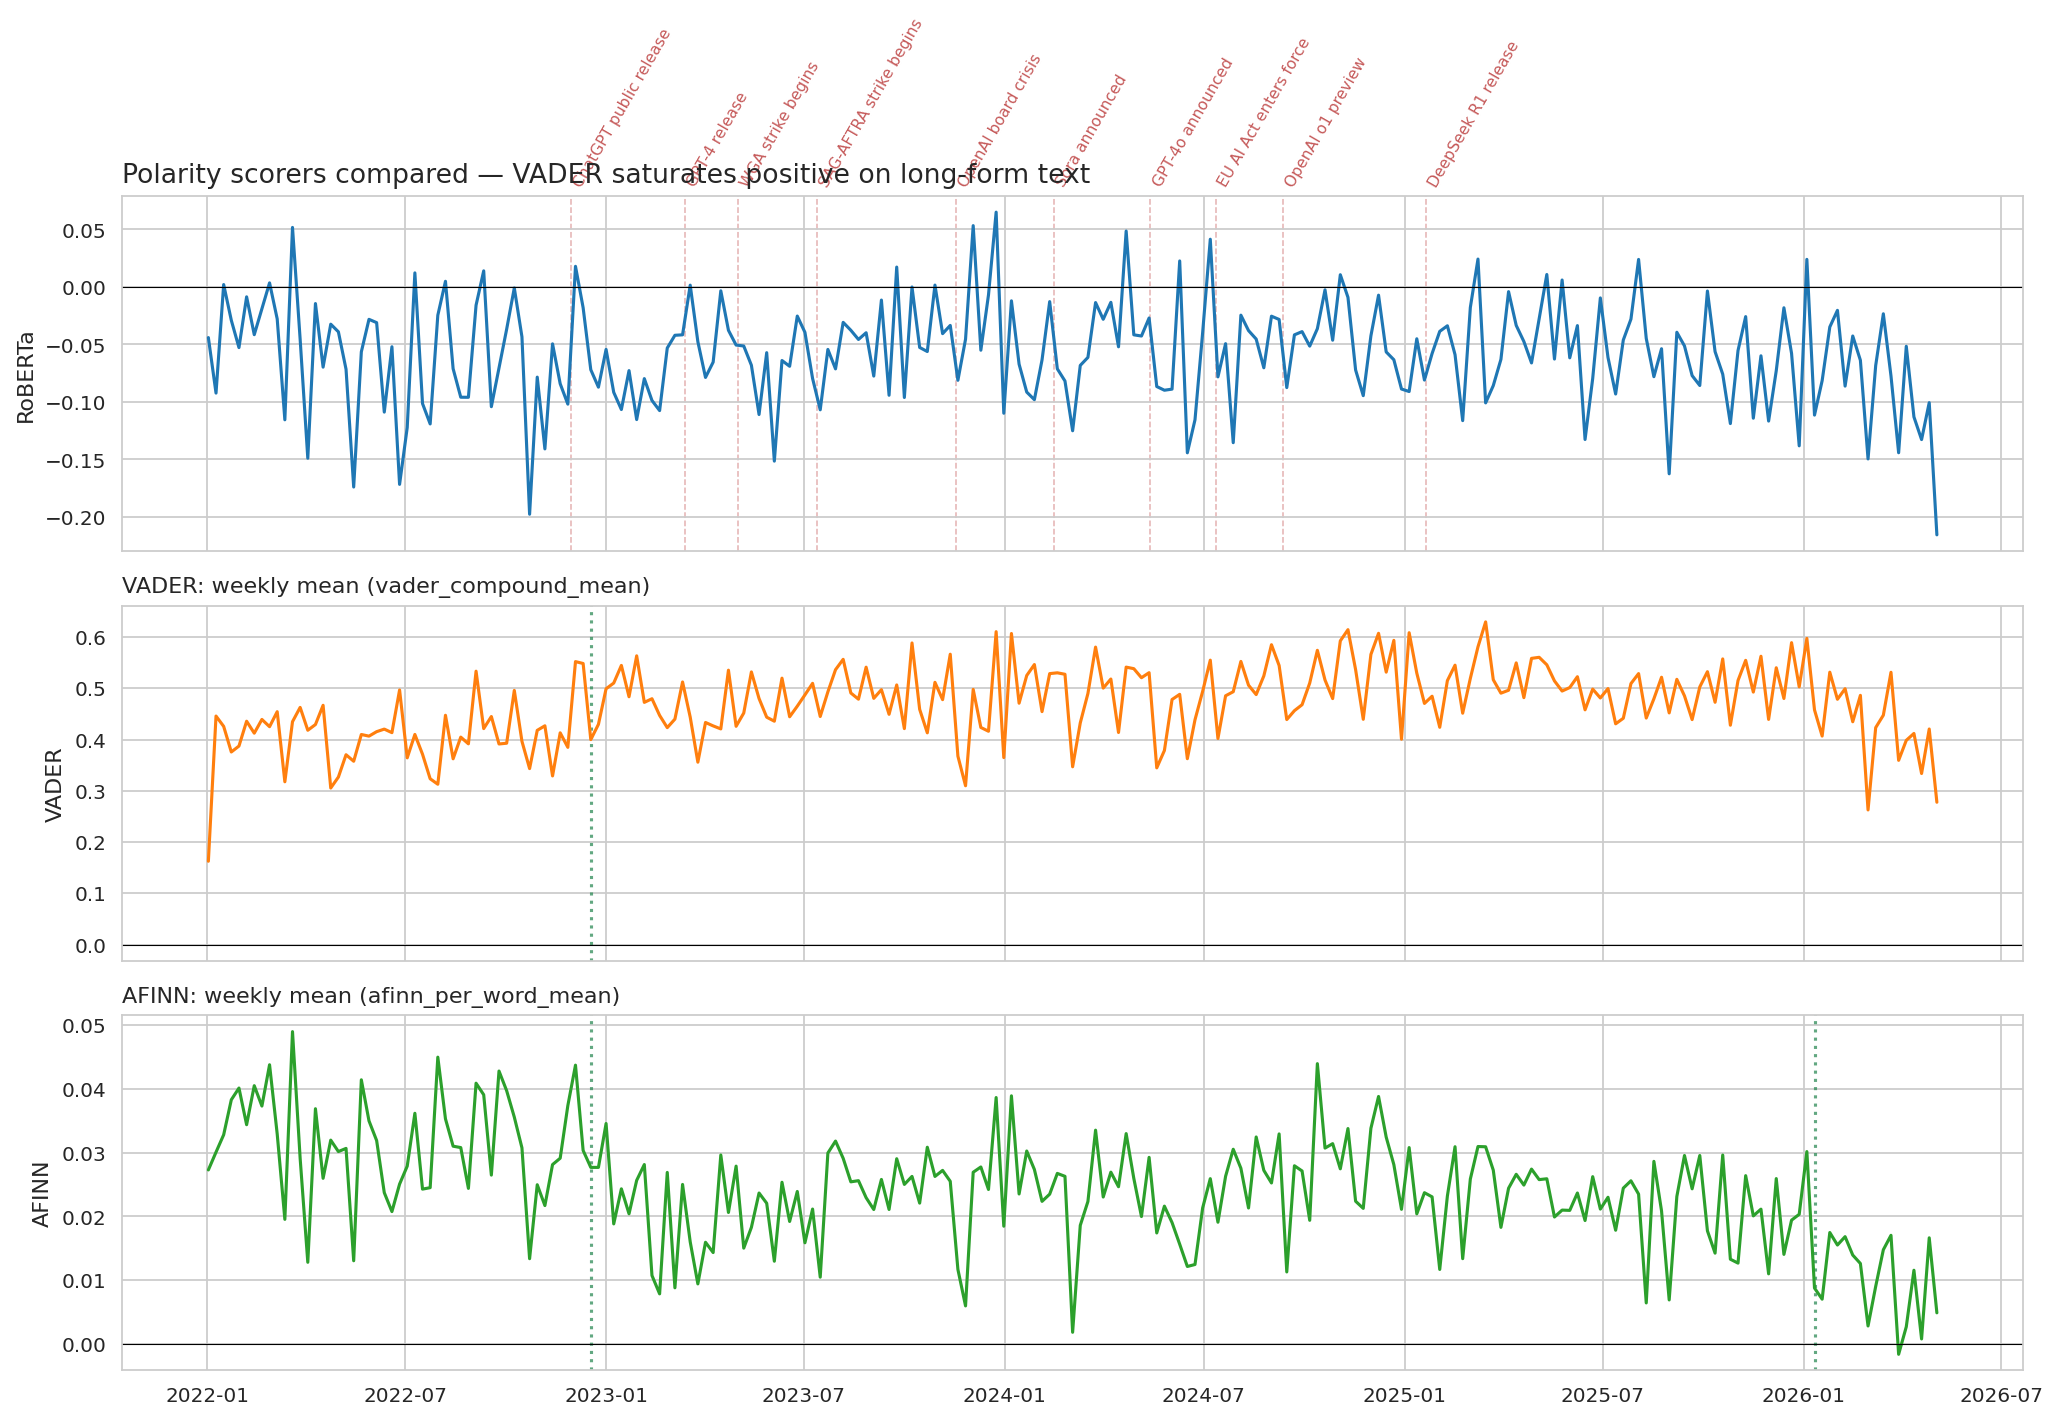

In [3]:
show('02_polarity_comparison.png')

## 3. Emotion arc — honeymoon to settling

**What is plotted.** Eight panels, one per NRC emotion. Each line is the weekly mean fraction of affective vocabulary that fell into that emotion category.

**What to look for.**
- Compare the 2022 starting level to the 2026 ending level for each emotion.
- Note the *magnitude* of each emotion (y-axis range): trust is much larger than the others.
- Group emotions by what they signal: excitement (anticipation, joy, surprise) vs negative tone (anger, fear, disgust, sadness) vs evaluative (trust).

**What we see.** The "excitement trio" — **anticipation, joy, surprise** — all decline. **Trust** dominates and stays stable. **Sadness** rises slightly. **Anger, fear, disgust** are stable at low baselines. Read together: a textbook hype-cycle settling pattern, observed quantitatively week-by-week across four years.

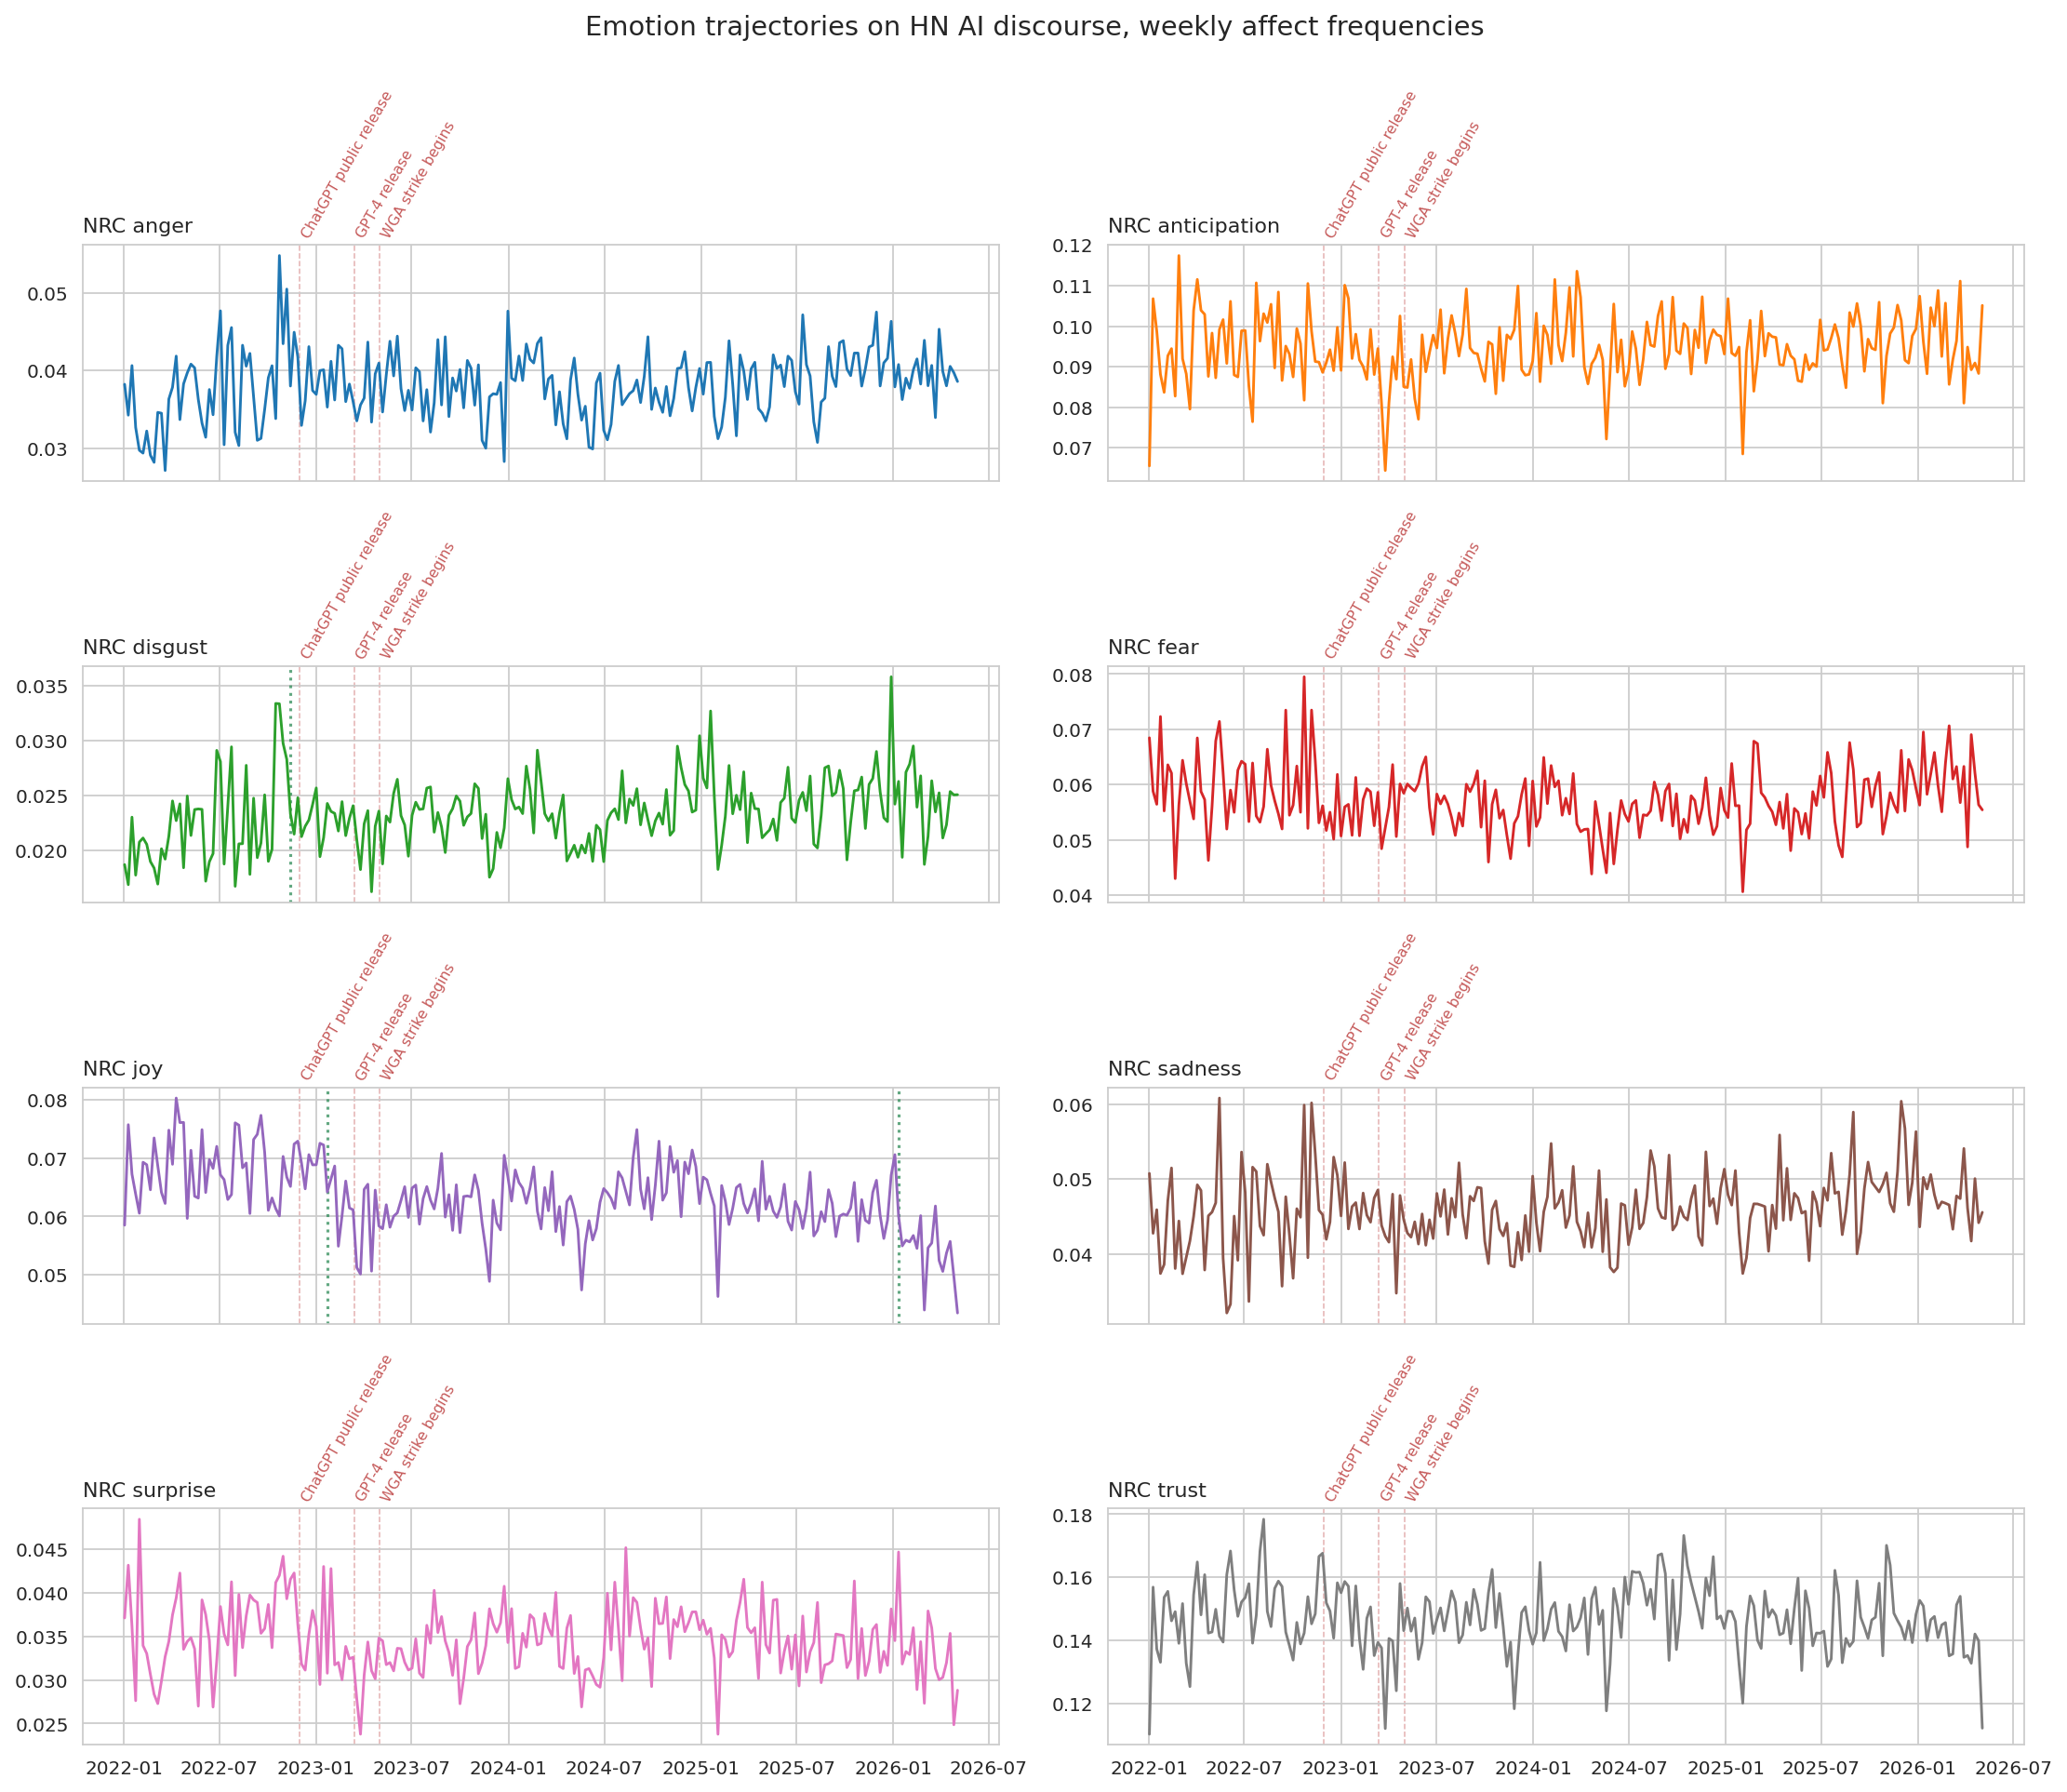

In [4]:
show('03_emotion_grid.png')

## 4. Hedging collapse

**What is plotted.** Hedge density per week — the fraction of sentences in each post that contain a hedging marker ("maybe", "I think", "could be", "seems like"). Higher = more uncertain language.

**What to look for.**
- The 2022 left edge (~0.38) vs the 2026 right edge (~0.18): roughly half.
- Multiple change-point lines (green dotted) — the algorithm sees this as a real, robust regime shift.
- Note that this is independent of polarity — it tracks *how confidently* people speak, not whether they're positive or negative.

**What we see.** A ~50% decline in hedging — the largest single quantitative effect in the corpus. As AI capabilities became concrete, the community stopped speaking in hypotheticals.

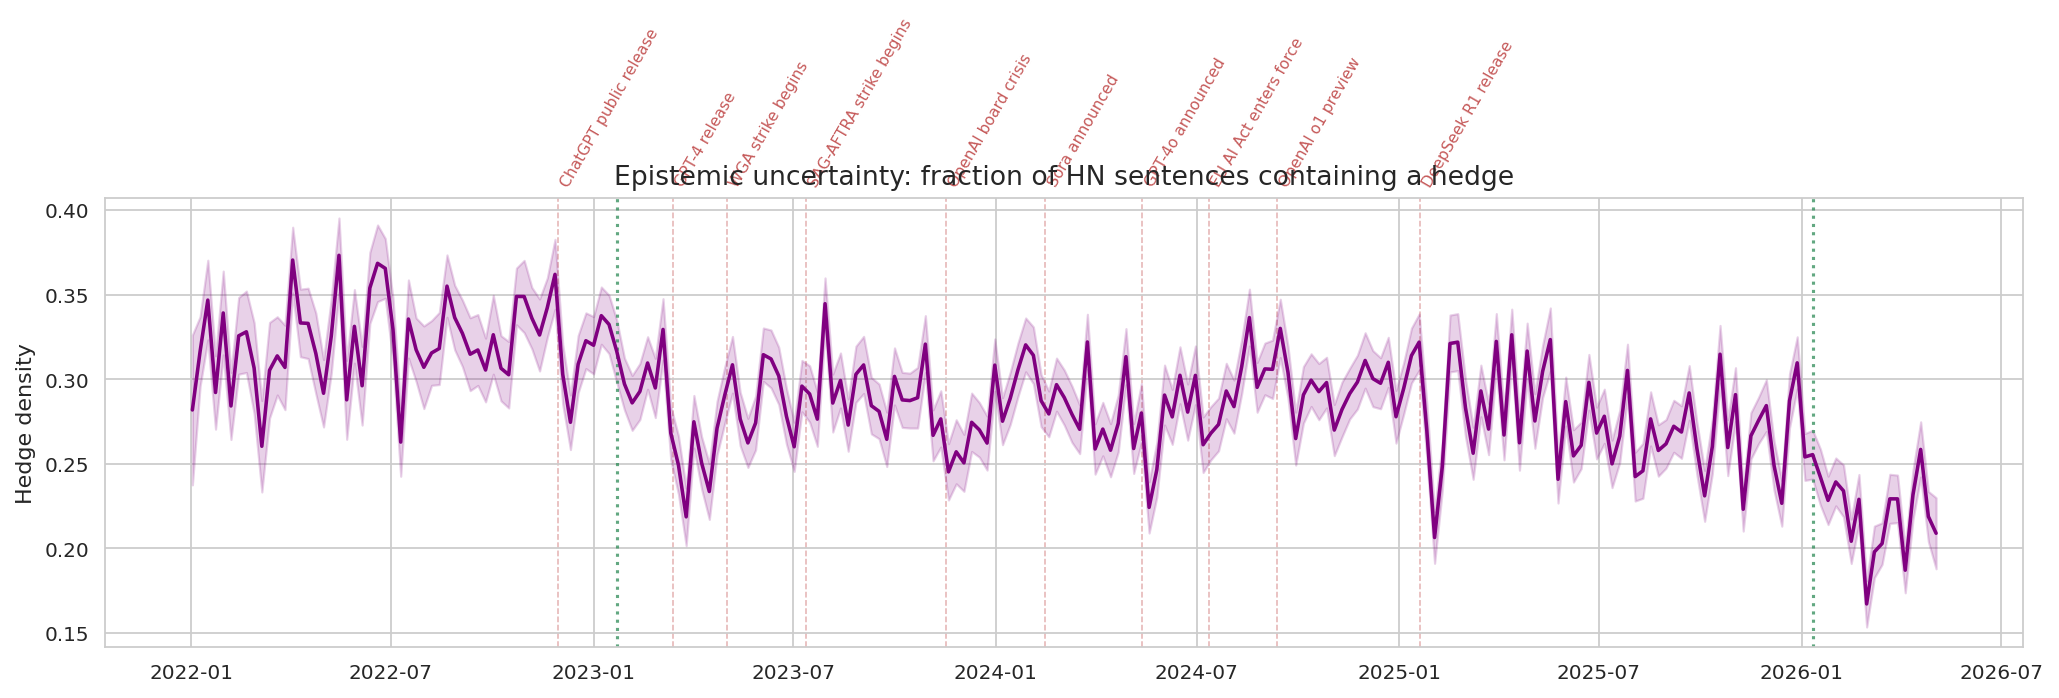

In [5]:
show('04_hedging.png')

## 5. Significant event-induced shifts

**What is plotted.** A forest plot of every (event × metric) pair that survived a Bonferroni-corrected significance threshold (p < 0.10) out of 140 tests total. Bar length = post-event mean minus pre-event mean (Welch t-test, ±30-day windows).

**What to look for.**
- Direction: every bar extends to the *left* (negative) or right (positive)? All eight here are leftward.
- Which metric pairs with which event — events that affect multiple metrics are more robust signals.
- The strength of the GPT-4 → hedge-density bar (largest leftmost) tells you which event had the most measurable single effect.

**What we see.** **All eight significant deltas are negative.** No event in our list significantly increased sentiment, hedging, or any positive emotion. Highlights: GPT-4 reduced hedging the most (Δ = −0.059, p ≈ 3×10⁻⁵). The OpenAI board crisis hit positivity hardest (Δ = −0.041 in NRC positive, also −0.10 in VADER). DeepSeek R1 *reduced negative emotions* (disgust, sadness) — the community welcomed it. **Pattern: capability releases convert speculation into evaluation.**

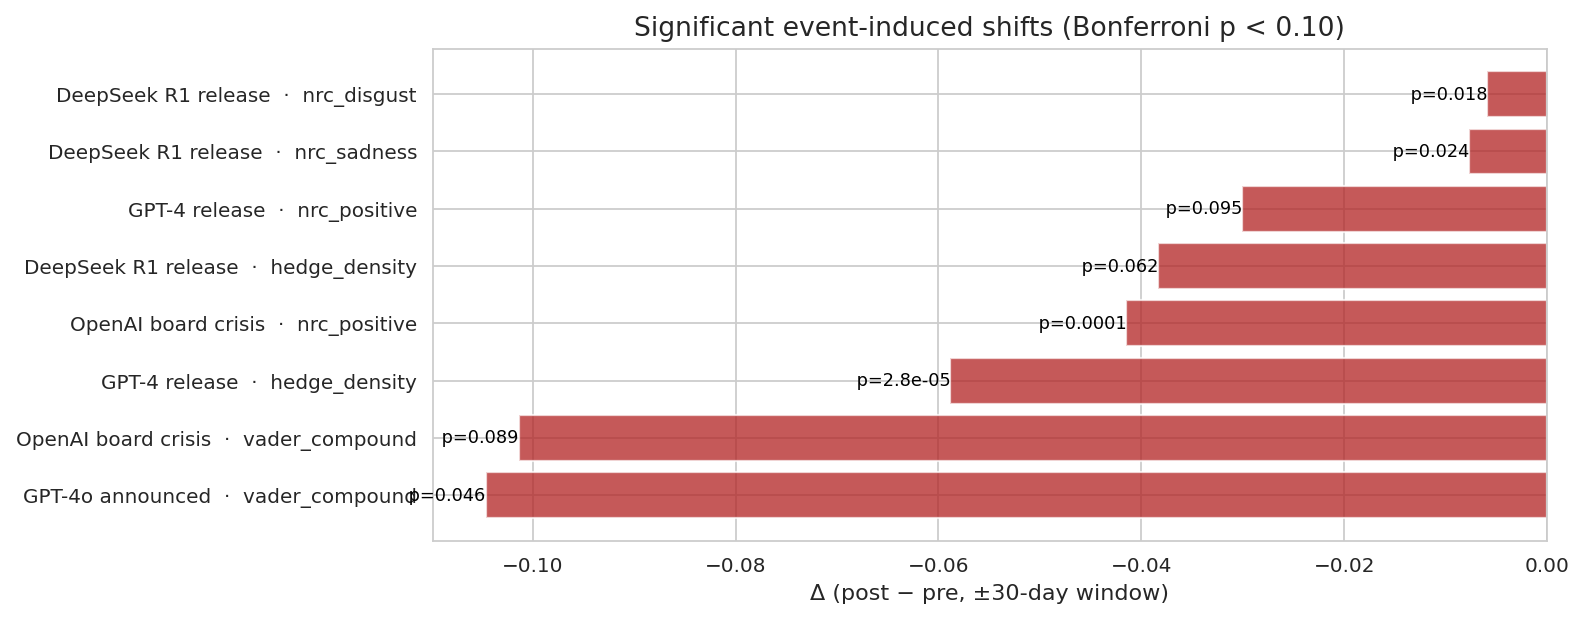

In [6]:
show('05_event_forest.png')

In [7]:
ev = pd.read_csv(RESULTS / 'event_tests.csv')
sig = ev[ev['p_bonferroni'] < 0.10].sort_values('p_bonferroni')
print(f'{len(ev)} total tests; {len(sig)} significant after Bonferroni:')
sig[['event', 'label', 'metric', 'mean_pre', 'mean_post', 'delta', 'p', 'p_bonferroni']]

140 total tests; 8 significant after Bonferroni:


,event,label,metric,mean_pre,mean_post,delta,p,p_bonferroni
131,2023-03-14,GPT-4 release,hedge_density,0.298303,0.239472,-0.058831,2.008983e-07,0.000028
34,2023-11-17,OpenAI board crisis,nrc_positive,0.280639,0.239159,-0.041480,7.327910e-07,0.000103
79,2025-01-20,DeepSeek R1 release,nrc_disgust,0.028476,0.022546,-0.005930,1.289139e-04,0.018048
109,2025-01-20,DeepSeek R1 release,nrc_sadness,0.049276,0.041541,-0.007735,1.733921e-04,0.024275
16,2024-05-13,GPT-4o announced,vader_compound,0.524534,0.419910,-0.104625,3.304468e-04,0.046263
139,2025-01-20,DeepSeek R1 release,hedge_density,0.304110,0.265788,-0.038322,4.436915e-04,0.062117
14,2023-11-17,OpenAI board crisis,vader_compound,0.493971,0.392598,-0.101373,6.325070e-04,0.088551
31,2023-03-14,GPT-4 release,nrc_positive,0.280999,0.250923,-0.030076,6.810639e-04,0.095349


## 6. Inter-metric correlations

**What is plotted.** A 14×14 matrix of Pearson correlations between every pair of document-level metrics. Red = positive correlation, blue = negative, white = independent.

**What to look for.**
- The diagonal is always 1.0 (each metric correlates perfectly with itself).
- Polarity scorers among themselves (top-left 3×3 block): how strong is their agreement?
- Emotion-emotion cells: do related emotions cluster (anger × disgust, sadness × fear)?
- Hedging row/column: does it correlate strongly with anything? If not, it's an independent dimension.

**What we see.** Polarity scorers correlate only modestly with each other (RoBERTa × VADER = 0.32, VADER × AFINN = 0.59) — they measure different aspects. Emotions cluster sensibly: anger × disgust = 0.42, anger × fear = 0.36, negative × anger = 0.46. **Hedging × polarity = −0.13** — hedging is essentially orthogonal to polarity, confirming it as a separate analytical axis. The matrix structure validates the decision to track multiple metrics rather than collapse to one.

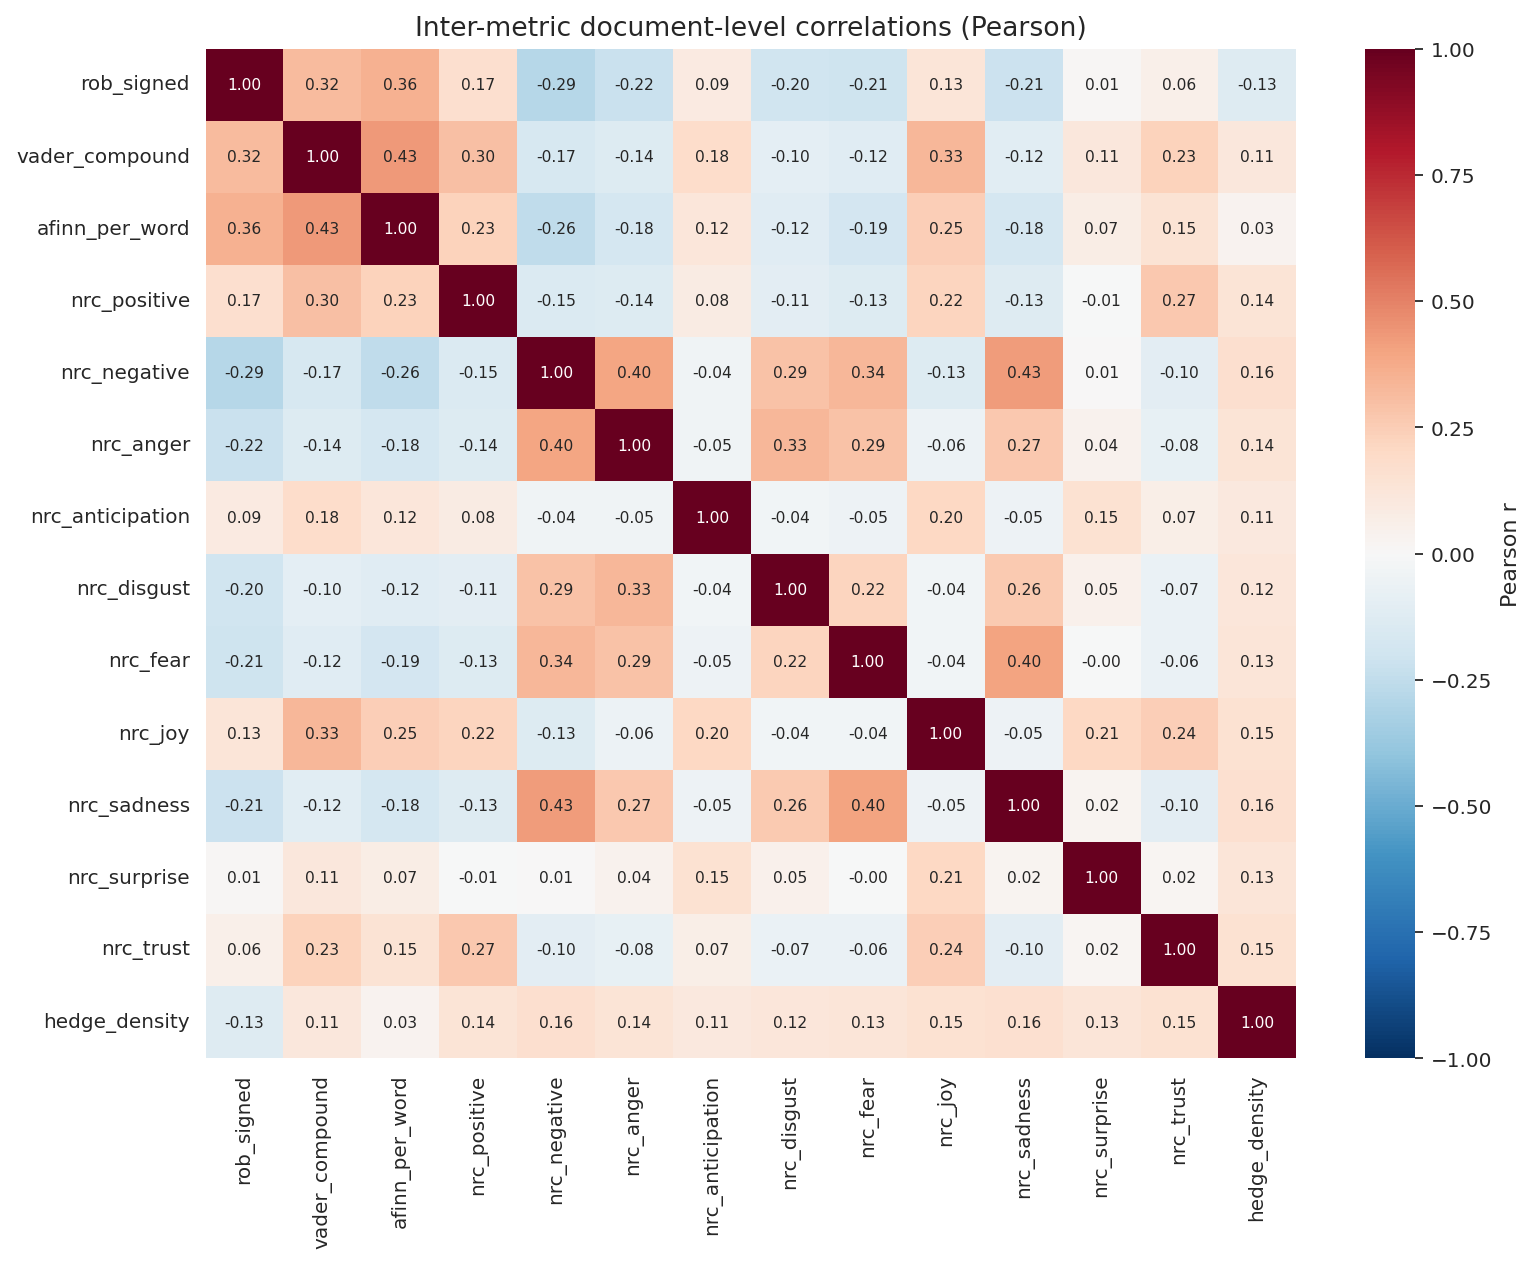

In [8]:
show('06_correlation_heatmap.png')

## 7. Topic × emotion structure

**What is plotted.** Top 15 topics (rows) × 8 NRC emotions (columns). Cell colour is z-scored within each emotion column — so it shows *relative* emphasis (red = unusually high for that emotion across topics). Annotated values are the raw mean.

**What to look for.**
- Read each row as the emotional fingerprint of one discourse area.
- Read each column as which topics over- or under-emphasize that emotion relative to the average.
- Outlier red cells flag topic-emotion combinations that depart from the corpus baseline.

**What we see.** Topic-specific emotional fingerprints are sharp. **Copyright/fair-use** is high in anger and disgust, low in joy. **Education impact** is high in joy and trust. **AI art** carries elevated disgust and anger. **Engineer/jobs/remote** has the highest trust, lowest fear — labor discourse is calm and substantive. **AGI / consciousness threads** show elevated fear. The headline mood drift is partly *which topics dominate when*, not uniform sentiment movement.

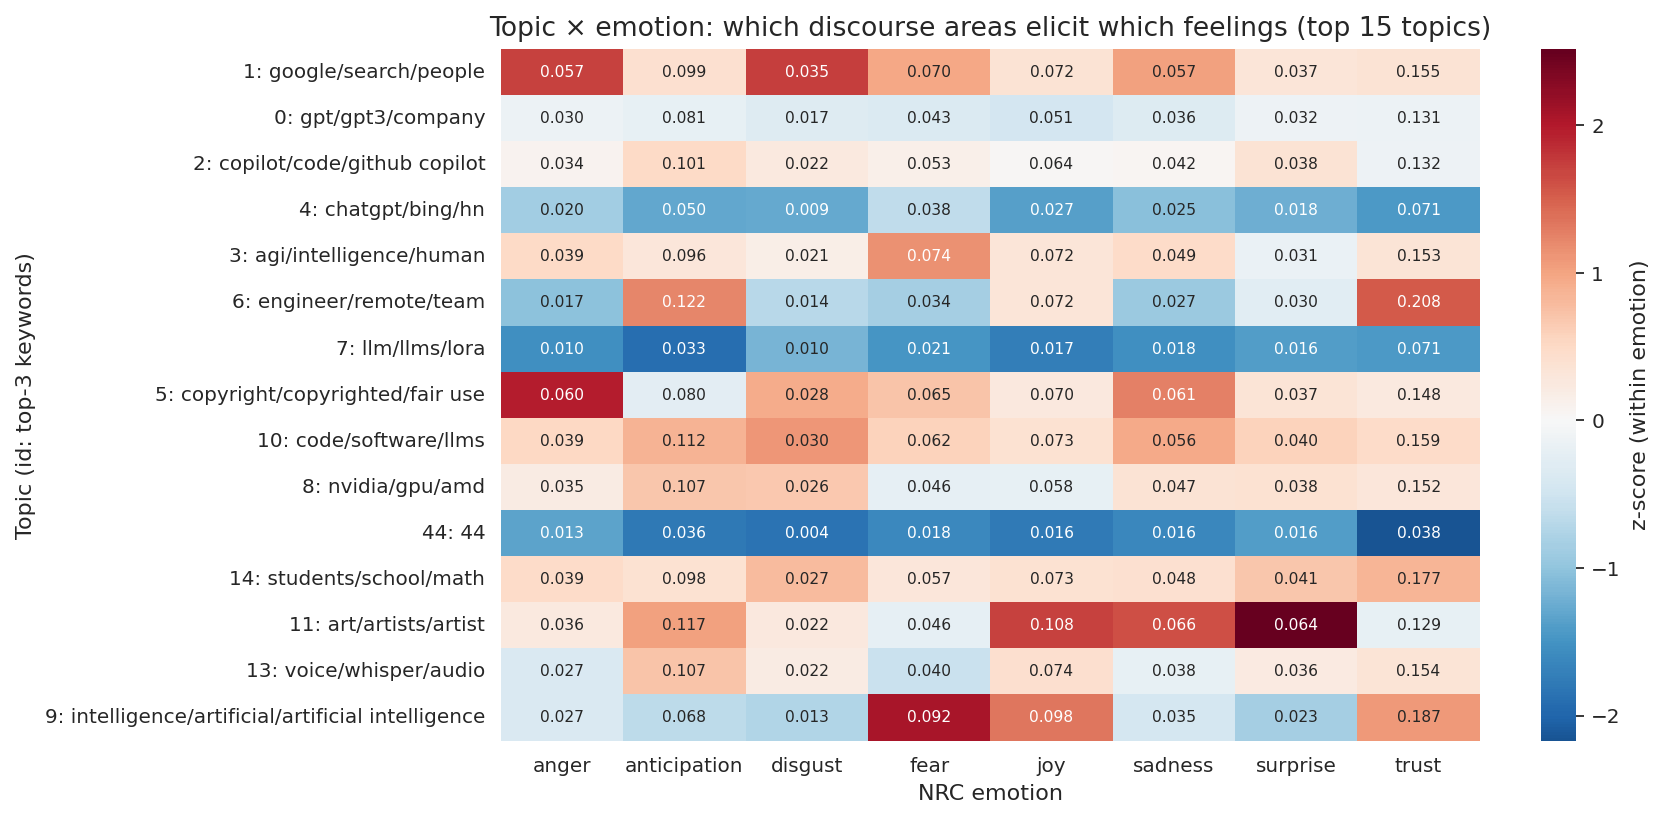

In [9]:
show('07_topic_emotion_heatmap.png')

## 8. Per-topic polarity over time

**What is plotted.** Top 8 topics by item count, each as a 4-week-smoothed weekly mean of RoBERTa polarity. The smoothing makes per-topic trends visible despite per-week noise.

**What to look for.**
- Which topics sit consistently above zero (positive) vs below?
- Which topics swing the most across the window (largest vertical range)?
- Do topics move in sync (suggesting platform-wide mood shifts) or independently (suggesting topic-specific events)?

**What we see.** Most topics drift mildly negative together, but **copyright/fair-use is consistently the most negative** — confirming the heatmap finding. Some topics (LLM/LoRA, Copilot) stay near neutral. The bands show that aggregate sentiment hides ±0.5 of topic-specific variation.

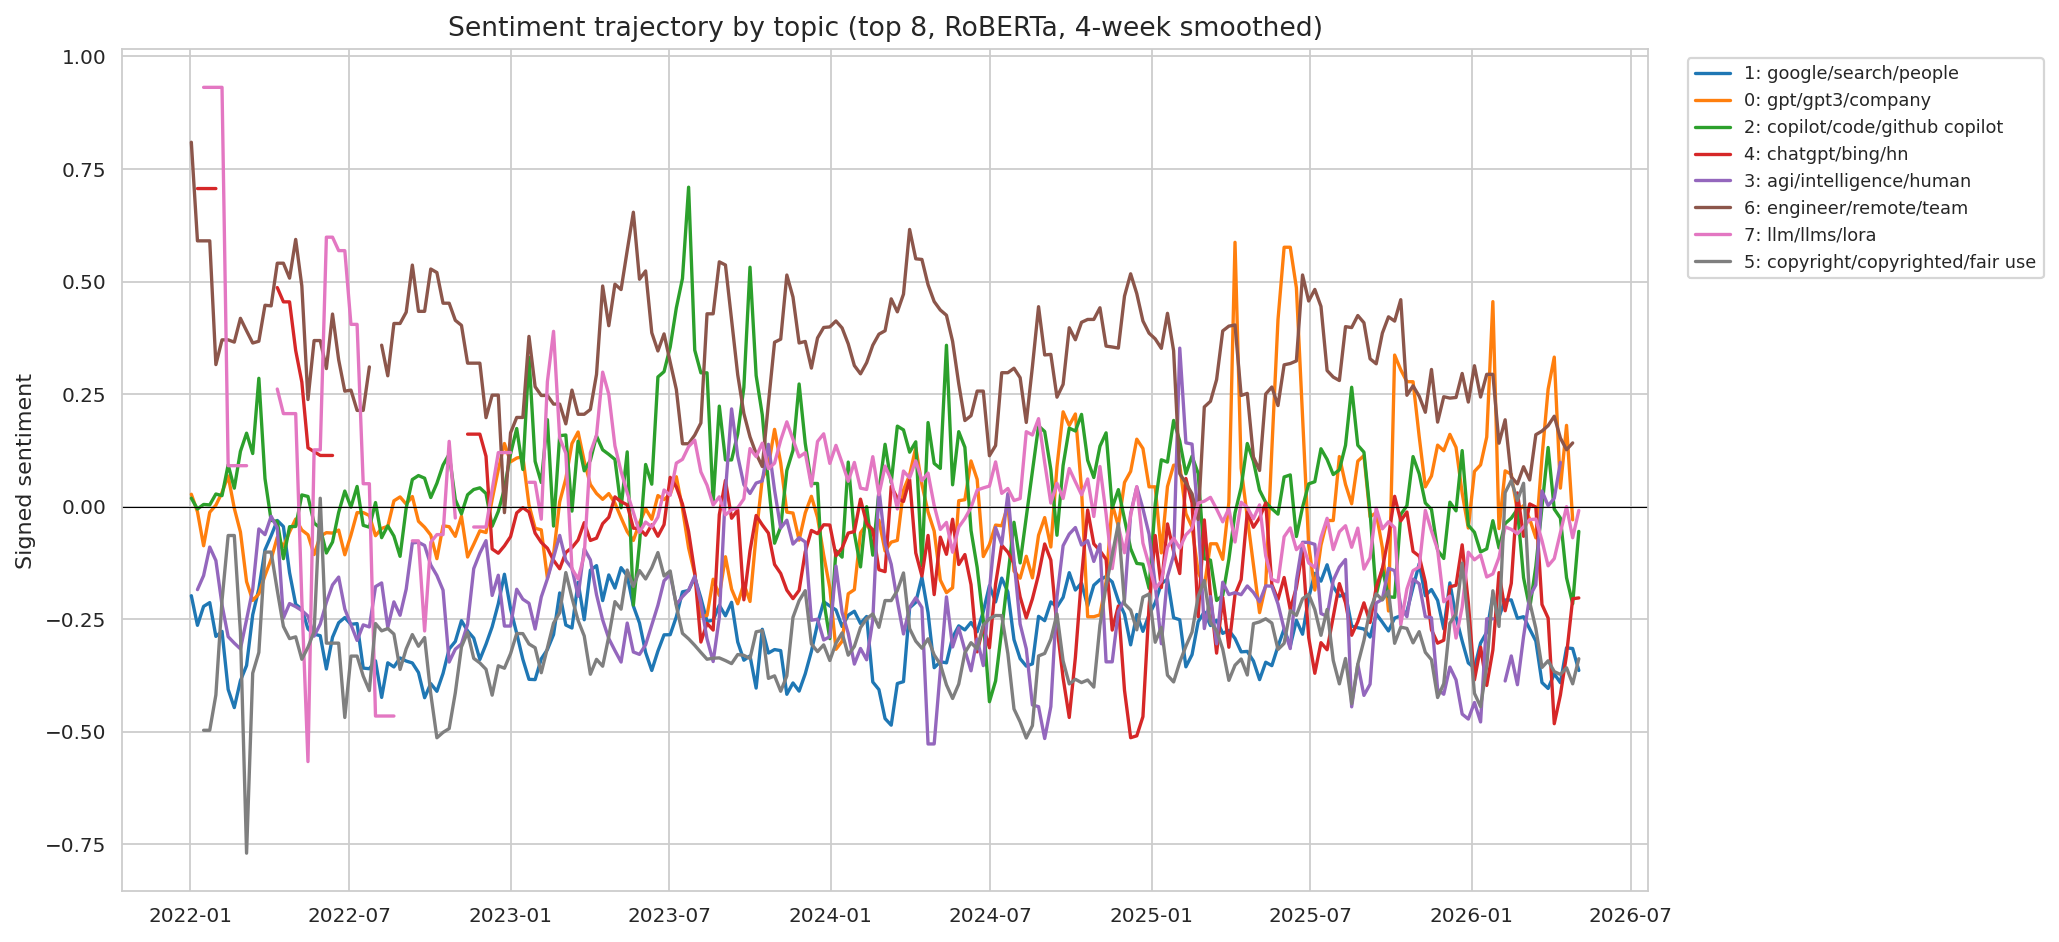

In [10]:
show('08_topic_polarity_trajectories.png')

## 9. Hedging vs polarity scatter

**What is plotted.** Each hex cell counts documents at a (RoBERTa polarity, hedge density) coordinate. Logarithmic colour scale (yellow = many documents, dark = few).

**What to look for.**
- Where is the densest mass? That's the typical HN comment.
- Is there a diagonal trend (negative slope = hedged texts more negative)?
- The shape of the cloud: tilted ellipse (correlated) or roughly circular (independent)?

**What we see.** Mass is concentrated near (polarity ≈ 0, hedge density ≈ 0.3) — typical HN comment is roughly neutral and moderately hedged. Pearson r = −0.13 (small). The cloud is broad in both axes, supporting the conclusion that hedging and polarity are largely orthogonal — measuring both adds information that neither alone provides.

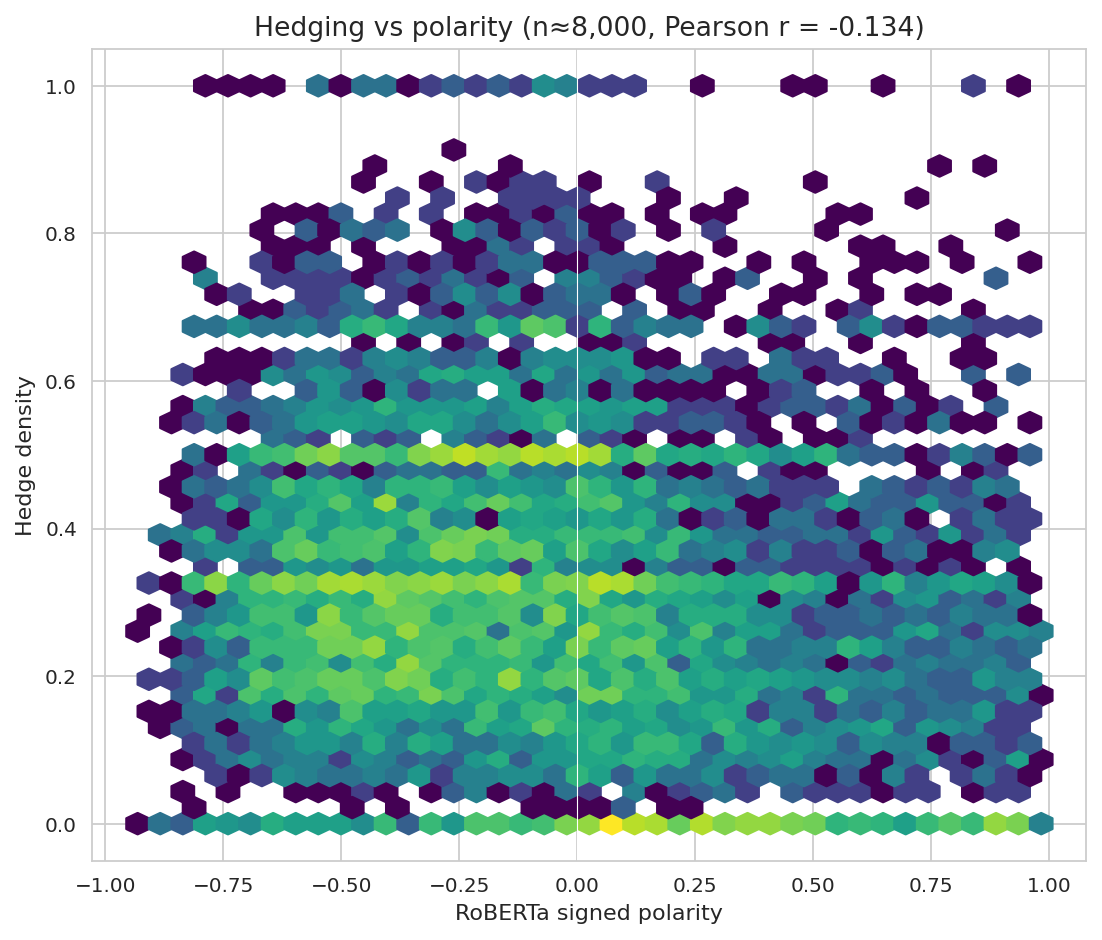

In [11]:
show('09_hedging_vs_polarity_scatter.png')

## 10. Topic catalog

**What this shows.** The 20 largest topic clusters with their top-10 representative keywords. Topic −1 is HDBSCAN's noise cluster (items that didn't fit any cluster well — typical for ~30% of real-world text).

**What to look for.** Use this as a key when reading the topic-numbered figures above. "Topic 5" in figure 7 corresponds to whatever's in row 5 of the table below.

In [12]:
from bertopic import BERTopic
model = BERTopic.load('../experiments/bertopic_hn')
info = model.get_topic_info().head(20)[['Topic', 'Count', 'Representation']]
info

c:\Projects\cs439-ai-sentiment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-06 01:34:27,127 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


,Topic,Count,Representation
0,-1,15682,"[ai, like, just, people, don, model, think, us..."
1,0,1781,"[gpt, gpt3, company, prompt, text, like, model..."
2,1,1564,"[google, search, people, content, like, just, ..."
3,2,993,"[copilot, code, github copilot, github, emacs,..."
4,3,911,"[agi, intelligence, human, humans, think, ai, ..."
5,4,836,"[chatgpt, bing, hn, chatgpt chatgpt, code, cha..."
6,5,687,"[copyright, copyrighted, fair use, fair, train..."
7,6,598,"[engineer, remote, team, experience, engineeri..."
8,7,528,"[llm, llms, lora, fine, fine tuning, tuning, t..."
9,8,403,"[nvidia, gpu, amd, memory, gpus, cuda, llama, ..."


## 11. Change-point detections

**What this shows.** All dates where the PELT algorithm detected a statistically meaningful regime shift in any metric's weekly trajectory. Penalty 3.0 is permissive (more detections); 10.0 is strict (only the most robust breaks survive).

**What to look for.**
- Dates that appear at multiple penalty levels for the same metric — those are the high-confidence breakpoints.
- Dates that recur across multiple metrics — those mark broad regime shifts in the discourse.
- December 2022 / January 2023 shows up repeatedly: the post-ChatGPT inflection.

In [13]:
cps = pd.read_csv(RESULTS / 'changepoints.csv', parse_dates=['breakpoint_date'])
cps['breakpoint_date'] = cps['breakpoint_date'].dt.date
print(f'{len(cps)} change-point detections across {cps.metric.nunique()} metrics')
cps.sort_values(['metric', 'penalty'])

32 change-point detections across 10 metrics


,metric,penalty,breakpoint_index,breakpoint_date
4,afinn_per_word,3.0,50,2022-12-18
5,afinn_per_word,3.0,210,2026-01-11
6,afinn_per_word,5.0,50,2022-12-18
7,afinn_per_word,5.0,210,2026-01-11
25,hedge_density,3.0,55,2023-01-22
26,hedge_density,3.0,180,2025-06-15
27,hedge_density,3.0,210,2026-01-11
28,hedge_density,5.0,55,2023-01-22
29,hedge_density,5.0,210,2026-01-11
30,hedge_density,10.0,55,2023-01-22


## 12. Summary findings, ranked

1. **HN sentiment toward generative AI is sliding.** The 2025–2026 trough is the most negative period of the entire window.
2. **Hedging collapsed by ~50%** between 2022 and 2026 — the largest single quantitative finding.
3. **VADER is unreliable on long-form text** — saturated positive throughout. A methodology-level finding worth reporting.
4. **Capability releases reduce both speculation and positivity.** Eight Bonferroni-significant negative shifts, no positive ones.
5. **Hype cycle is measurable.** Joy ↓, anticipation ↓, surprise ↓; trust stable; sadness slightly ↑.
6. **Topic-level emotional structure is rich.** Copyright is angry; education is hopeful; art is contentious. Aggregate-level signals mask this.
7. **Multi-dimensional measurement is justified.** Polarity scorers correlate only r ≈ 0.32–0.59; hedging is orthogonal to polarity.